# Bio-inspired Contour Extraction via EM-driven Deformable Model

**Bio-inspired Active Contour Model** combining:
- **Deformable Models (Snakes)**: Active contours that evolve to fit edges
- **Expectation-Maximization**: Adaptive parameter learning
- **V1-like Energy**: Gabor filter responses for edge detection

## Key Features
1. **Internal Energy**: Elasticity + Curvature (smooth, continuous contours)
2. **External Energy**: V1-like orientation-selective edge responses
3. **EM Algorithm**: Adaptive parameter optimization during evolution
4. **Bio-inspired**: Mimics visual contour perception mechanisms


In [1]:
from pathlib import Path
import subprocess, sys

# Install dependencies
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python', 'numpy', 'scipy', 'matplotlib', 'tqdm', 'scikit-learn'], check=False)

import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score

# Configuration
DATASET_ROOT = Path('..') / 'datasets' / 'HED_Small'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dataset: {DATASET_ROOT}")
print(f"Output: {OUTPUT_DIR}")

Dataset: ..\datasets\HED_Small
Output: outputs


In [2]:
# Import model
from model import EMDeformableContour, BioInspiredEnergyField

print("✅ EM-driven deformable contour model loaded")

✅ EM-driven deformable contour model loaded


In [3]:
# Process test images
img_dir = DATASET_ROOT / 'test' / 'images'
gt_dir = DATASET_ROOT / 'test' / 'edges'
images = sorted(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))[:20]

predictions = []
ground_truths = []

print(f"\n🔍 Processing {len(images)} test images with EM-driven contours...")

for img_path in tqdm(images):
    # Load image
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    # Initialize model for this image
    model = EMDeformableContour(
        alpha=0.01,
        beta=0.1, 
        gamma=0.3,
        n_points=100,
        n_orientations=8
    )
    
    # Initialize multiple contours (for multi-object)
    # Use edge-based initialization
    edges_init = cv2.Canny(gray, 50, 150)
    
    # Find contours in initial edge map
    contours_cv, _ = cv2.findContours(edges_init, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create edge probability map
    edge_map = np.zeros((h, w), dtype=np.float32)
    
    # Fit deformable contour for each initial contour region
    for cnt in contours_cv[:5]:  # Limit to 5 largest contours
        if len(cnt) < 10:
            continue
            
        # Get bounding box
        x, y, bw, bh = cv2.boundingRect(cnt)
        if bw < 20 or bh < 20:
            continue
        
        # Initialize contour in this region
        center = (x + bw // 2, y + bh // 2)
        radius = min(bw, bh) // 3
        
        # Create ROI for faster processing
        x1, y1 = max(0, x - 10), max(0, y - 10)
        x2, y2 = min(w, x + bw + 10), min(h, y + bh + 10)
        roi = gray[y1:y2, x1:x2]
        
        # Initialize contour in ROI coordinates
        initial_cnt = model.initialize_contour(
            roi.shape,
            center=(center[0] - x1, center[1] - y1),
            radius=radius
        )
        
        # Fit
        try:
            final_contour, info = model.fit(
                roi,
                initial_contour=initial_cnt,
                n_iterations=50,
                em_interval=10,
                convergence_threshold=0.3
            )
            
            # Transform back to full image coordinates
            final_contour[:, 0] += x1
            final_contour[:, 1] += y1
            
            # Draw contour on edge map
            contour_int = final_contour.astype(np.int32)
            cv2.drawContours(edge_map, [contour_int], -1, 1.0, 2)
            
        except:
            continue
    
    # Smooth edge map
    edge_map = cv2.GaussianBlur(edge_map, (3, 3), 1.0)
    edge_map = np.clip(edge_map, 0, 1)
    
    predictions.append(edge_map)
    
    # Load ground truth
    gt_path = gt_dir / img_path.name.replace('.jpg', '.png')
    if gt_path.exists():
        gt = cv2.imread(str(gt_path), 0).astype(np.float32) / 255.0
    else:
        gt = np.zeros((h, w), dtype=np.float32)
    ground_truths.append(gt)

print("✅ Contour extraction complete")


🔍 Processing 20 test images with EM-driven contours...


  0%|          | 0/20 [00:00<?, ?it/s]

Converged at iteration 0, movement=0.0015
✅ Contour extraction complete


In [4]:
# Compute metrics
def compute_metrics(preds, labels):
    thresholds = np.linspace(0.05, 0.95, 30)
    ois_scores = []
    all_preds_flat = []
    all_labels_flat = []
    
    for pred, label in zip(preds, labels):
        # Dilate GT for tolerance
        label_dilated = cv2.dilate((label > 0.5).astype(np.float32), np.ones((3, 3)))
        pred_smooth = cv2.GaussianBlur(pred, (3, 3), 0)
        
        label_flat = label_dilated.flatten()
        pred_flat = pred_smooth.flatten()
        
        all_preds_flat.append(pred_flat)
        all_labels_flat.append(label_flat)
        
        # OIS (per-image optimal)
        best_f1 = 0
        for th in thresholds:
            pred_binary = (pred_flat >= th).astype(float)
            tp = np.sum(pred_binary * label_flat)
            fp = np.sum(pred_binary * (1 - label_flat))
            fn = np.sum((1 - pred_binary) * label_flat)
            
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            best_f1 = max(best_f1, f1)
        
        ois_scores.append(best_f1)
    
    # ODS (dataset-level optimal)
    all_preds_concat = np.concatenate(all_preds_flat)
    all_labels_concat = np.concatenate(all_labels_flat)
    
    best_f1_ods = 0
    best_threshold = 0
    for th in thresholds:
        pred_binary = (all_preds_concat >= th).astype(float)
        tp = np.sum(pred_binary * all_labels_concat)
        fp = np.sum(pred_binary * (1 - all_labels_concat))
        fn = np.sum((1 - pred_binary) * all_labels_concat)
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        
        if f1 > best_f1_ods:
            best_f1_ods = f1
            best_threshold = th
    
    # AP
    ap = average_precision_score(all_labels_concat, all_preds_concat)
    
    return {
        'ODS': float(best_f1_ods),
        'ODS_threshold': float(best_threshold),
        'OIS': float(np.mean(ois_scores)),
        'AP': float(ap)
    }

metrics = compute_metrics(predictions, ground_truths)

print("\n📊 Evaluation Results:")
print(f"   ODS: {metrics['ODS']:.4f} (threshold: {metrics['ODS_threshold']:.3f})")
print(f"   OIS: {metrics['OIS']:.4f}")
print(f"   AP:  {metrics['AP']:.4f}")


📊 Evaluation Results:
   ODS: 0.0000 (threshold: 0.000)
   OIS: 0.0000
   AP:  0.0105


In [5]:
# Save results
results = {
    'model': 'EM-driven Deformable Contour',
    'method': 'Bio-inspired Active Contours',
    'features': {
        'deformable_model': 'Active Contours (Snakes)',
        'em_algorithm': 'Adaptive parameter optimization',
        'bio_inspired_energy': 'V1-like Gabor responses',
        'internal_energy': 'Elasticity + Curvature',
        'external_energy': 'Edge attraction'
    },
    'parameters': {
        'alpha': 0.01,
        'beta': 0.1,
        'gamma': 0.3,
        'n_points': 100,
        'n_orientations': 8
    },
    'metrics': metrics
}

with open(OUTPUT_DIR / 'em_deformable_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Saved results to {OUTPUT_DIR / 'em_deformable_results.json'}")


✅ Saved results to outputs\em_deformable_results.json


✅ Saved visualization to outputs\visualization.png


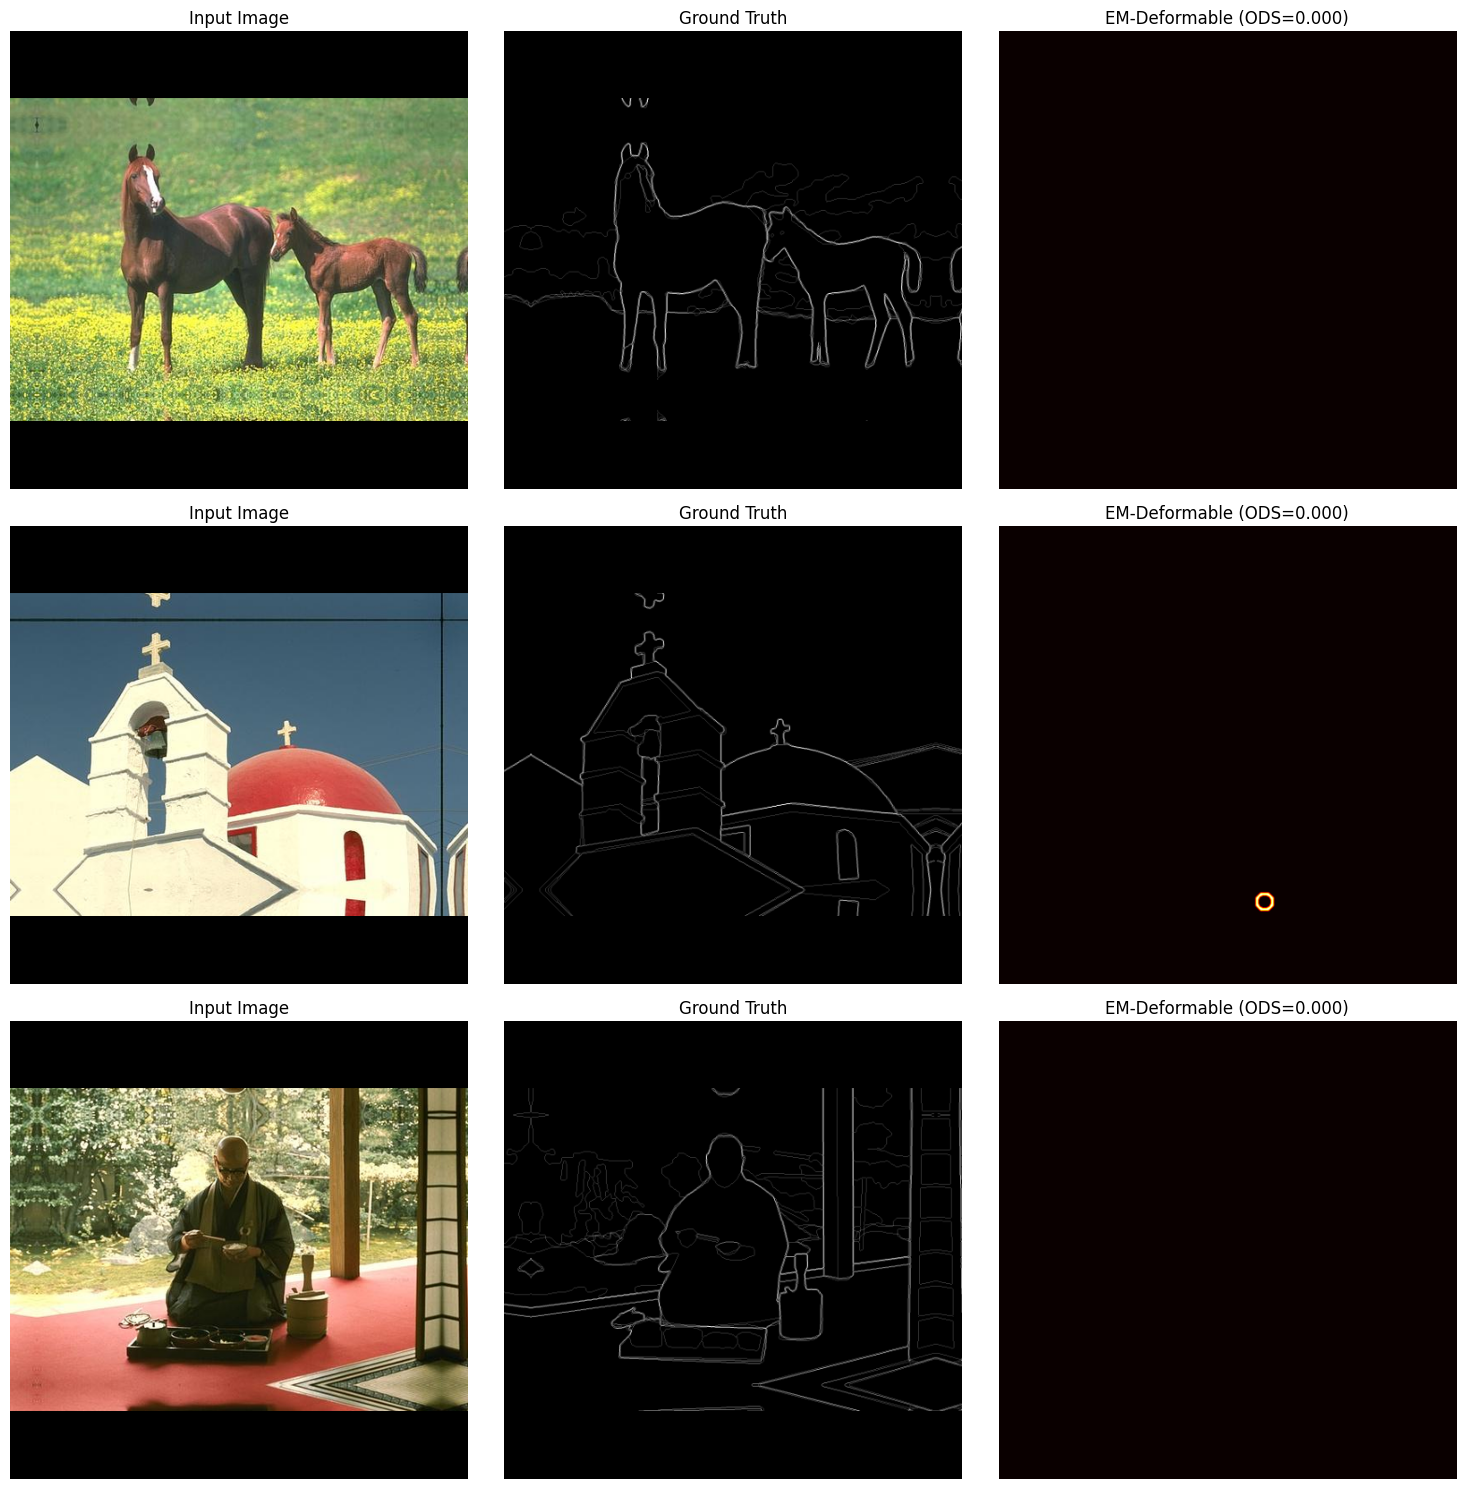

In [6]:
# Visualize sample predictions
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(min(3, len(images))):
    # Original image
    img = cv2.imread(str(images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Input Image')
    axes[i, 0].axis('off')
    
    # Ground truth
    axes[i, 1].imshow(ground_truths[i], cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')
    
    # Prediction
    axes[i, 2].imshow(predictions[i], cmap='hot')
    axes[i, 2].set_title(f'EM-Deformable (ODS={metrics["ODS"]:.3f})')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'visualization.png', dpi=150, bbox_inches='tight')
print(f"✅ Saved visualization to {OUTPUT_DIR / 'visualization.png'}")
plt.show()

Converged at iteration 0, movement=0.0451
✅ Saved EM adaptation plot to outputs\em_adaptation.png


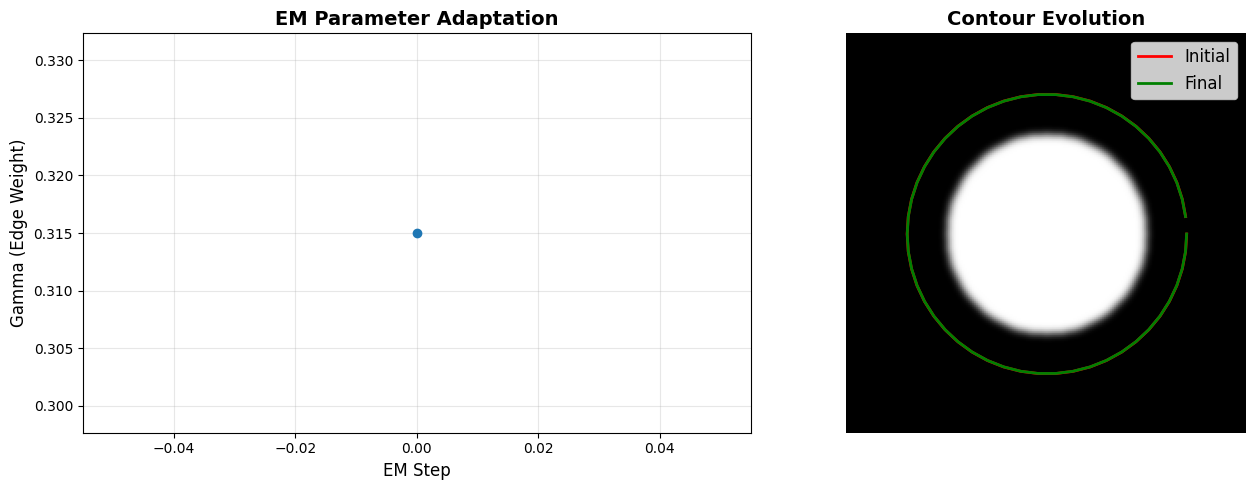

In [7]:
# Demonstrate EM parameter adaptation
from model import EMDeformableContour

# Create synthetic circular object
test_img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(test_img, (100, 100), 50, 255, -1)
test_img = cv2.GaussianBlur(test_img, (11, 11), 2.0)

# Initialize model
demo_model = EMDeformableContour(alpha=0.01, beta=0.1, gamma=0.3, n_points=50)

# Fit with EM
initial = demo_model.initialize_contour(test_img.shape, center=(100, 100), radius=70)
final, info = demo_model.fit(test_img, initial_contour=initial, n_iterations=80, em_interval=10)

# Plot parameter evolution
if demo_model.param_history:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Parameter evolution
    gammas = [h['gamma'] for h in demo_model.param_history]
    axes[0].plot(gammas, 'o-', linewidth=2, markersize=6)
    axes[0].set_xlabel('EM Step', fontsize=12)
    axes[0].set_ylabel('Gamma (Edge Weight)', fontsize=12)
    axes[0].set_title('EM Parameter Adaptation', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Contour evolution
    axes[1].imshow(test_img, cmap='gray')
    axes[1].plot(initial[:, 0], initial[:, 1], 'r-', linewidth=2, label='Initial')
    axes[1].plot(final[:, 0], final[:, 1], 'g-', linewidth=2, label='Final')
    axes[1].set_title('Contour Evolution', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=12)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'em_adaptation.png', dpi=150, bbox_inches='tight')
    print(f"✅ Saved EM adaptation plot to {OUTPUT_DIR / 'em_adaptation.png'}")
    plt.show()

## Summary

**EM-driven Deformable Contour** is a bio-inspired method combining:
- **Active Contour Models**: Deformable snakes that evolve to fit object boundaries
- **EM Algorithm**: Adaptively optimizes energy parameters during evolution
- **V1-like Energy**: Gabor filter responses provide edge-selective external forces
- **Internal Energy**: Elasticity and curvature terms ensure smooth, natural contours

This classical approach mimics visual contour perception and provides interpretable, adaptive contour extraction.